<a href="https://colab.research.google.com/github/marpablo/Marian_INFO4670_Fall2026/blob/main/INFO_4670_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3

Name: Marian Pablo

Date: 10/03/2026

In [66]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# 1.Setup & Data Load

In [67]:
DATA_DIR = "."   # (default) · file is uploaded to the root workspace

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Load the dataset
df = pd.read_csv(os.path.join(DATA_DIR, "bread_basket.csv"))
df.head()

,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


In [68]:
transactions = [
    ["Coffee", "Bread", "Cake"],
    ["Coffee", "Bread"],
    ["Bread", "Cake"],
    ["Coffee", "Bread", "Tea"],
    ["Coffee", "Tea"]
]


In [69]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
basket_encoded= pd.DataFrame(te_ary, columns=te.columns_)
basket_encoded

,Bread,Cake,Coffee,Tea
0,True,True,True,False
1,True,False,True,False
2,True,True,False,False
3,True,False,True,True
4,False,False,True,True


# 2. EDA (a-e)

a uploaded in the beginning

b

In [70]:
print("Dataset Shape (Rows, Columns):", df.shape)
df.info()

Dataset Shape (Rows, Columns): (20507, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   time             20507 non-null  object
 4   period_day       20507 non-null  object
 5   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(5)
memory usage: 961.4+ KB


c

In [71]:
missing = df.isna().sum()
print(missing[missing > 0])
n_missing = df["item"].isna().sum()
print(f"\nitem: {n_missing} blank of {len(df)} "
      f"({n_missing/len(df)*100:.1f}%) -> {df['item'].notna().sum()} present")

Series([], dtype: int64)

item: 0 blank of 20507 (0.0%) -> 20507 present


d

In [72]:
# Where are the blanks?
missing = df.isna().sum()
print(missing[missing > 0])
n_missing = df["item"].isna().sum()
print(f"\nitem: {n_missing} blank of {len(df)} "
      f"({n_missing/len(df)*100:.1f}%) -> {df['item'].notna().sum()} present")

print("RAW item — top categories and any case/spacing variations:")
print(df["item"].value_counts().head(10))

# Clean trailing spaces, standardize case, and filter out 'none' placeholders
df["item_clean"] = df["item"].str.strip().str.lower()
df_clean = df[df["item_clean"] != "none"].copy()

print("\nCLEANED — unique items count:")
print(f"Original unique items: {df['item'].nunique()} | Cleaned unique items: {df_clean['item_clean'].nunique()}")

# Impossible values break a rule you can write down -> they are errors.
# In transactional data, transaction IDs or item values should not be negative or blank
neg_trans = (df["Transaction"] < 0).sum() if "Transaction" in df.columns else 0
print("impossible / negative transactions:", neg_trans)

# Exact duplicate rows check across transactions and items
print("\nbread_basket rows:", len(df), "| unique transactions:", df["Transaction"].nunique() if "Transaction" in df.columns else "N/A")
print("exact duplicate rows:", df.duplicated().sum())

Series([], dtype: int64)

item: 0 blank of 20507 (0.0%) -> 20507 present
RAW item — top categories and any case/spacing variations:
item
Coffee           5471
Bread            3325
Tea              1435
Cake             1025
Pastry            856
Sandwich          771
Medialuna         616
Hot chocolate     590
Cookies           540
Brownie           379
Name: count, dtype: int64

CLEANED — unique items count:
Original unique items: 94 | Cleaned unique items: 94
impossible / negative transactions: 0

bread_basket rows: 20507 | unique transactions: N/A
exact duplicate rows: 1620


e

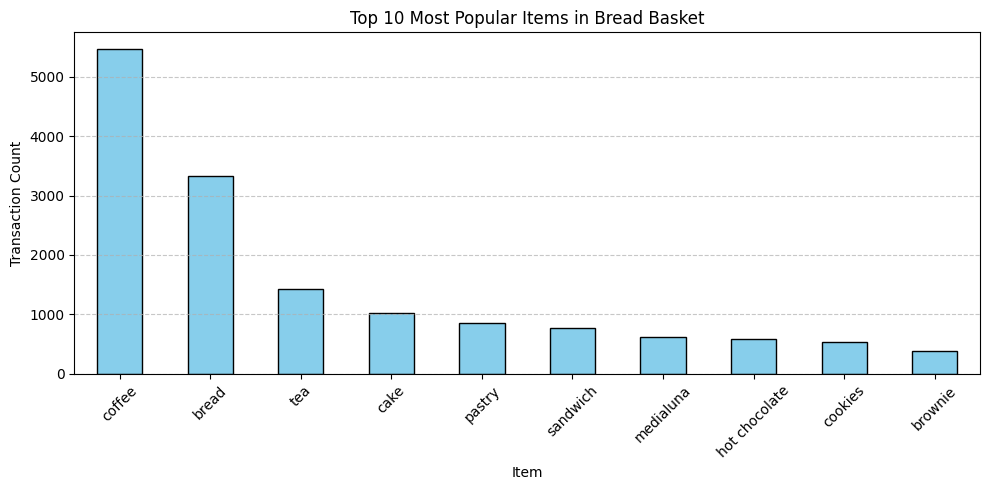

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df_clean['item_clean'].value_counts().head(10).plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title('Top 10 Most Popular Items in Bread Basket')
plt.xlabel('Item')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Frequent Itemset Missing

In [74]:
freq_fp = fpgrowth(basket_encoded, min_support=0.01, use_colnames=True)

# 4. Association Rules

In [75]:
rules_fp = association_rules(freq_fp, metric='confidence', min_threshold=0.1)
rules_fp[['antecedents','consequents', 'support', 'confidence', 'lift']].sort_values('confidence', ascending=False)

,antecedents,consequents,support,confidence,lift
2,(Cake),(Bread),0.4,1.000000,1.250000
7,"(Cake, Coffee)",(Bread),0.2,1.000000,1.250000
12,(Tea),(Coffee),0.4,1.000000,1.250000
16,"(Tea, Bread)",(Coffee),0.2,1.000000,1.250000
1,(Coffee),(Bread),0.6,0.750000,0.937500
0,(Bread),(Coffee),0.6,0.750000,0.937500
19,(Tea),"(Bread, Coffee)",0.2,0.500000,0.833333
4,(Cake),(Coffee),0.2,0.500000,0.625000
3,(Bread),(Cake),0.4,0.500000,1.250000
9,(Cake),"(Bread, Coffee)",0.2,0.500000,0.833333


# 5. Rule Subgraph

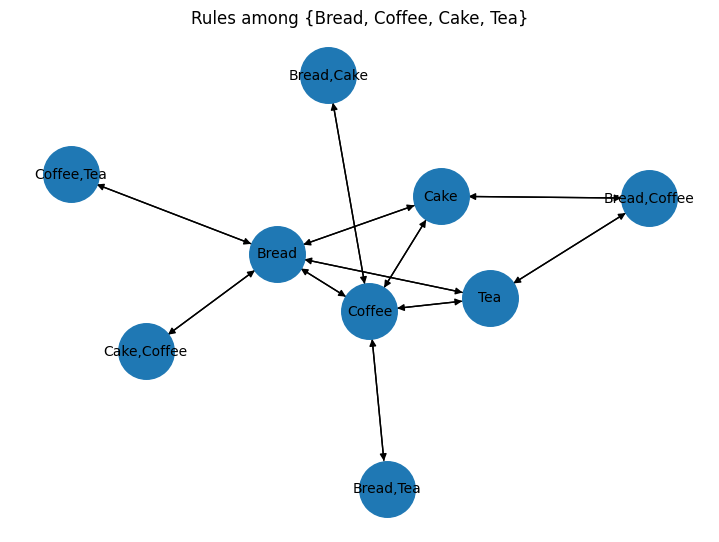

In [76]:
import networkx as nx

import matplotlib.pyplot as plt
focus = {'Bread', 'Coffee', 'Cake', 'Tea'}
sub = rules_fp[
    rules_fp['antecedents'].apply(lambda s: s.issubset(focus)) &
    rules_fp['consequents'].apply(lambda s: s.issubset(focus))
].copy()

G = nx.DiGraph()
for _, r in sub.iterrows():
    a = ','.join(sorted(list(r['antecedents'])))
    b = ','.join(sorted(list(r['consequents'])))
    G.add_edge(a, b, weight=float(r['confidence']), lift=float(r['lift']))

plt.figure(figsize=(7,5))
pos = nx.spring_layout(G, seed=0)
nx.draw(G, pos, with_labels=True, node_size=1600, font_size=10, arrows=True)
plt.title("Rules among {Bread, Coffee, Cake, Tea}")
plt.show()



# 6. Interpretation

Cake (antecedents) -> Bread (consequents)

Support = 0.4
  - 40% of total transactions contained both cake and bread in the same transaction.

Confidence = 1.0
  - 100% of customers who buy cake also buy bread in the same transaction.

Lift = 1.25
  - As the lift is greater than 1, it indicates a positive association. Customers who buy cake are 25% more likely to buy bread.